In [1]:
import pandas as pd
import matplotlib as mpl
import statsmodels.formula.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as s
import statsmodels.api as sm

In [2]:
tb1 = pd.read_excel('dummy.xlsx')
tb1

,servicecall,months_since_last_service,type_of_repair,repair_time_in_hours
0,1,2,electrical,2.9
1,2,6,mechanical,3.0
2,3,8,electrical,4.8
3,4,3,mechanical,1.8
4,5,2,electrical,2.9
5,6,7,electrical,4.9
6,7,9,mechanical,4.2
7,8,8,mechanical,4.8
8,9,4,electrical,4.4
9,10,6,electrical,4.5


Text(0.5, 1.0, 'Simple linear regression')

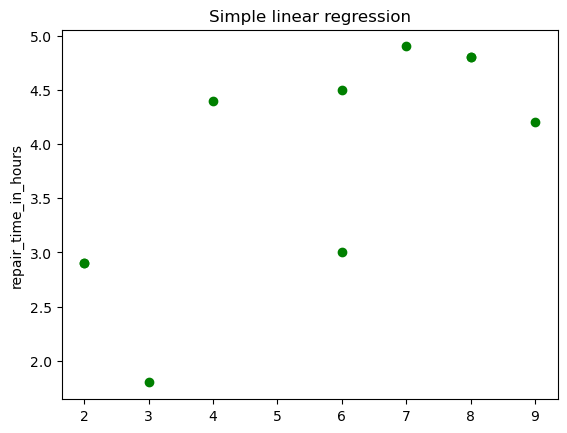

In [3]:
plt.scatter(tb1['months_since_last_service'], 
            tb1['repair_time_in_hours'], 
            color='green')
plt.ylabel('repair_time_in_hours')
plt.title('Simple linear regression')

In [4]:
from statsmodels.formula.api import ols
Reg = ols(formula='repair_time_in_hours ~ months_since_last_service', 
          data=tb1)
Fit1 = Reg.fit()
print(Fit1.summary())

                             OLS Regression Results                             
Dep. Variable:     repair_time_in_hours   R-squared:                       0.534
Model:                              OLS   Adj. R-squared:                  0.476
Method:                   Least Squares   F-statistic:                     9.174
Date:                  Fri, 03 Apr 2026   Prob (F-statistic):             0.0163
Time:                          01:06:04   Log-Likelihood:                -10.602
No. Observations:                    10   AIC:                             25.20
Df Residuals:                         8   BIC:                             25.81
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
In

In [5]:
influence = Fit1.get_influence()
resid_student = influence.resid_studentized_external

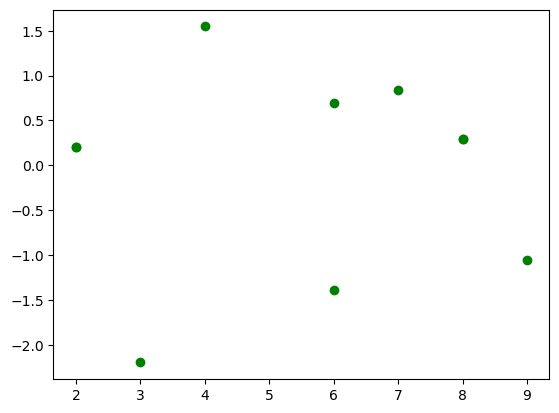

In [6]:
plt.figure()
plt.scatter(tb1['months_since_last_service'], resid_student, color='green')

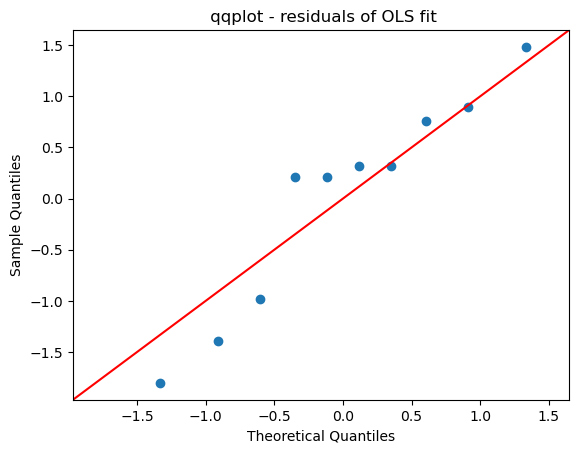

In [7]:
res = Fit1.resid   # Residuals
probplot = s.ProbPlot(res, stats.norm, fit=True)
fig = probplot.qqplot(line='45')
h = plt.title(' qqplot - residuals of OLS fit')
plt.show()

In [8]:
just_dummies = pd.get_dummies(tb1['type_of_repair'])
just_dummies

,electrical,mechanical
0,True,False
1,False,True
2,True,False
3,False,True
4,True,False
5,True,False
6,False,True
7,False,True
8,True,False
9,True,False


In [9]:
just_dummies = pd.get_dummies(tb1['type_of_repair'])
step_1 = pd.concat((tb1, just_dummies), axis=1)
step_1
step_1.drop(['type_of_repair', 'mechanical'], inplace = True, axis = 1)

In [10]:
step_1

,servicecall,months_since_last_service,repair_time_in_hours,electrical
0,1,2,2.9,True
1,2,6,3.0,False
2,3,8,4.8,True
3,4,3,1.8,False
4,5,2,2.9,True
5,6,7,4.9,True
6,7,9,4.2,False
7,8,8,4.8,False
8,9,4,4.4,True
9,10,6,4.5,True


In [11]:
step_1['electrical'] = step_1['electrical'].astype(int)
result = s.OLS(
    step_1['repair_time_in_hours'],
    s.add_constant(step_1[['months_since_last_service', 'electrical']])
).fit()
print(result.summary())

                             OLS Regression Results                             
Dep. Variable:     repair_time_in_hours   R-squared:                       0.859
Model:                              OLS   Adj. R-squared:                  0.819
Method:                   Least Squares   F-statistic:                     21.36
Date:                  Fri, 03 Apr 2026   Prob (F-statistic):            0.00105
Time:                          01:06:07   Log-Likelihood:                -4.6200
No. Observations:                    10   AIC:                             15.24
Df Residuals:                         7   BIC:                             16.15
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
co

In [12]:
tbl2 = pd.read_excel('dummy2.xlsx')
tbl2

,Employee,Salary,Gender,Experience
0,1,7.5,Male,6
1,2,8.6,Male,10
2,3,9.1,Male,12
3,4,10.3,Male,18
4,5,13.0,Male,30
5,6,6.2,Female,5
6,7,8.7,Female,13
7,8,9.4,Female,15
8,9,9.8,Female,21


Text(0.5, 1.0, 'Simple linear regression')

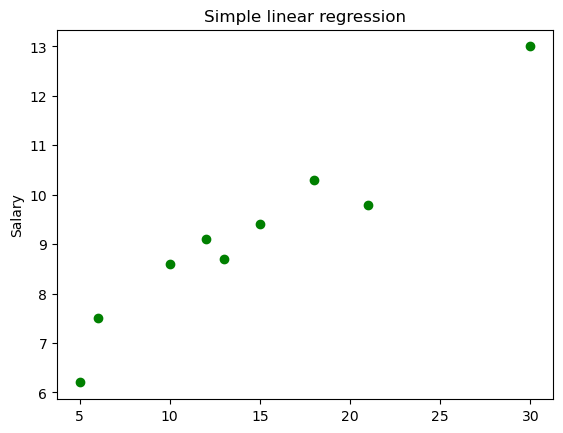

In [13]:
plt.scatter(tbl2['Experience'], tbl2['Salary'], color='green')
plt.ylabel('Salary')
plt.title('Simple linear regression')

In [14]:
Reg2 = ols(formula='Salary ~ Experience', data=tbl2)
Fit2 = Reg2.fit()
print(Fit2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     87.61
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           3.30e-05
Time:                        01:06:09   Log-Likelihood:                -6.2491
No. Observations:                   9   AIC:                             16.50
Df Residuals:                       7   BIC:                             16.89
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.8093      0.404     14.386      0.0

In [15]:
influence = Fit2.get_influence()
resid_student = influence.resid_studentized_external

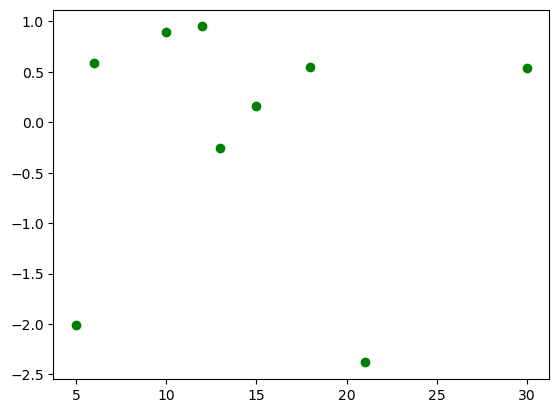

In [16]:
plt.figure()
plt.scatter(tbl2['Experience'], resid_student, color='green')

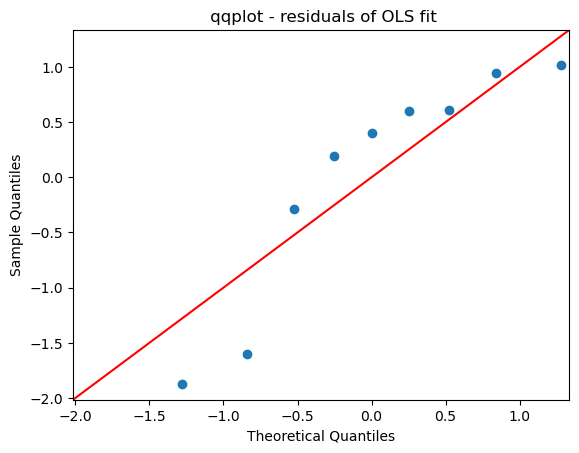

In [17]:
res = Fit2.resid   # Residuals
probplot = s.ProbPlot(res, stats.norm, fit=True)
fig = probplot.qqplot(line='45')
h = plt.title(' qqplot - residuals of OLS fit')
plt.show()

In [18]:
just_dummies2 = pd.get_dummies(tbl2['Gender'])
just_dummies2

,Female,Male
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True
5,True,False
6,True,False
7,True,False
8,True,False


In [19]:
step_1 = pd.concat([tbl2, just_dummies2], axis=1)
step_1.drop(['Gender', 'Male'], inplace=True, axis=1)
step_1['Female'] = step_1['Female'].astype(int)
step_1['Salary'] = pd.to_numeric(step_1['Salary'])
result = sm.OLS(
    step_1['Salary'],
    sm.add_constant(step_1[['Female']])
).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.8426
Date:                Fri, 03 Apr 2026   Prob (F-statistic):              0.389
Time:                        01:06:12   Log-Likelihood:                -17.455
No. Observations:                   9   AIC:                             38.91
Df Residuals:                       7   BIC:                             39.30
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.7000      0.853     11.367      0.0

In [20]:
result = sm.OLS(
    step_1['Salary'],
    sm.add_constant(step_1[['Female', 'Experience']])
).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     111.6
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           1.80e-05
Time:                        01:06:12   Log-Likelihood:                -1.5752
No. Observations:                   9   AIC:                             9.150
Df Residuals:                       6   BIC:                             9.742
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.2485      0.291     21.439      0.0

In [21]:
step_1 = pd.concat([tbl2, just_dummies2], axis=1)
step_1.drop(['Gender', 'Female'], inplace=True, axis=1)

In [22]:
step_1['Male'] = step_1['Male'].astype(int)
step_1['Salary'] = pd.to_numeric(step_1['Salary'])
result = sm.OLS(
    step_1['Salary'],
    sm.add_constant(step_1[['Male']])
).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.8426
Date:                Fri, 03 Apr 2026   Prob (F-statistic):              0.389
Time:                        01:06:13   Log-Likelihood:                -17.455
No. Observations:                   9   AIC:                             38.91
Df Residuals:                       7   BIC:                             39.30
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.5250      0.954      8.935      0.0